<a href="https://colab.research.google.com/github/binshadbin42-coder/github-tutorial/blob/main/Rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muthuj7/weather-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.23M/2.23M [00:00<00:00, 126MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/muthuj7/weather-dataset/versions/1


In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
import os
os.listdir(path)

['weatherHistory.csv']

In [9]:
dataset_train=pd.read_csv(os.path.join(path,"weatherHistory.csv"))
dataset_train.head(10)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


In [13]:
dataset_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [23]:
dataset_train["Formatted Date"] = pd.to_datetime(dataset_train["Formatted Date"], utc=True)

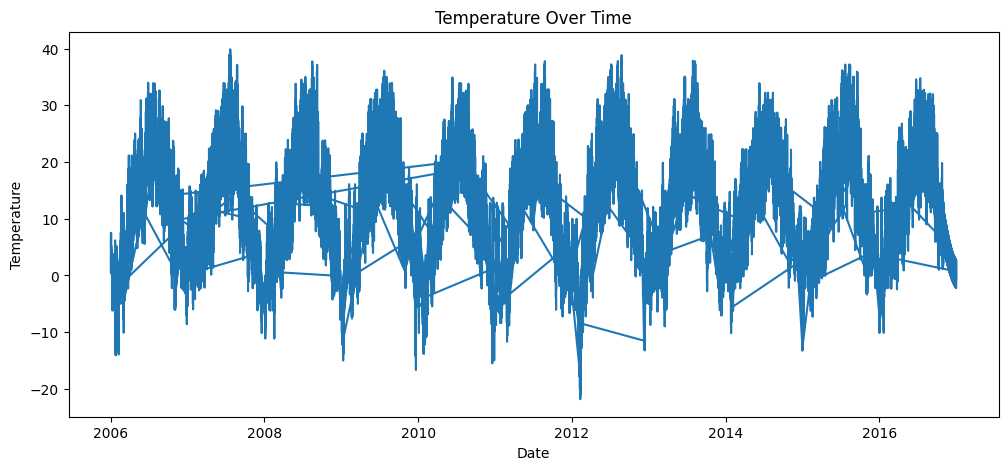

In [25]:
plt.figure(figsize=(12,5))
plt.plot(dataset_train["Formatted Date"], dataset_train["Temperature (C)"])
plt.title("Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

In [16]:
print(dataset_train.isnull().sum())

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64


In [27]:
data = dataset_train[["Formatted Date", "Temperature (C)", "Humidity", "Wind Speed (km/h)", "Pressure (millibars)"]]

In [31]:
from sklearn.preprocessing import MinMaxScaler

# Exclude 'Formatted Date' column before scaling
data_for_scaling = data.drop('Formatted Date', axis=1)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_for_scaling)

In [34]:
sequence_length = 7
X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i, 0])  # Temperature is the first column

X, y = np.array(X), np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (96446, 7, 4)
y Shape: (96446,)


In [36]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (77156, 7, 4)
X_test Shape: (19290, 7, 4)
y_train Shape: (77156,)
y_test Shape: (19290,)


In [40]:
from warnings import simplefilter
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

model = Sequential()

model.add(SimpleRNN(32, input_shape=(7, 4), return_sequences=True))
model.add(SimpleRNN(64))

model.add(Dropout(0.2))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [41]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 7, 32)          │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,457 (29.13 KB)

 Trainable params: 7,457 (29.13 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 7.1046e-04 - mae: 0.0184 - val_loss: 4.1487e-04 - val_mae: 0.0134
Epoch 2/50
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 7.0763e-04 - mae: 0.0184 - val_loss: 4.0577e-04 - val_mae: 0.0130
Epoch 3/50
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 7.0826e-04 - mae: 0.0183 - val_loss: 4.0734e-04 - val_mae: 0.0131
Epoch 4/50
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 7.0725e-04 - mae: 0.0184 - val_loss: 4.0639e-04 - val_mae: 0.0130
Epoch 5/50
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 7.0149e-04 - mae: 0.0183 - val_loss: 4.1425e-04 - val_mae: 0.0132
Epoch 6/50
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 7.0953e-04 - mae: 0.0184 - val_loss: 4.7820e-04 - val_mae: 0.0159
Epoch 7/50
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 7.1252e-04 - mae: 0.0185 - val_loss: 4.3459e-04 - val_mae: 0.0145
Epoch 8/50
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 7.0787e-04 - mae: 0.0184 - val_los

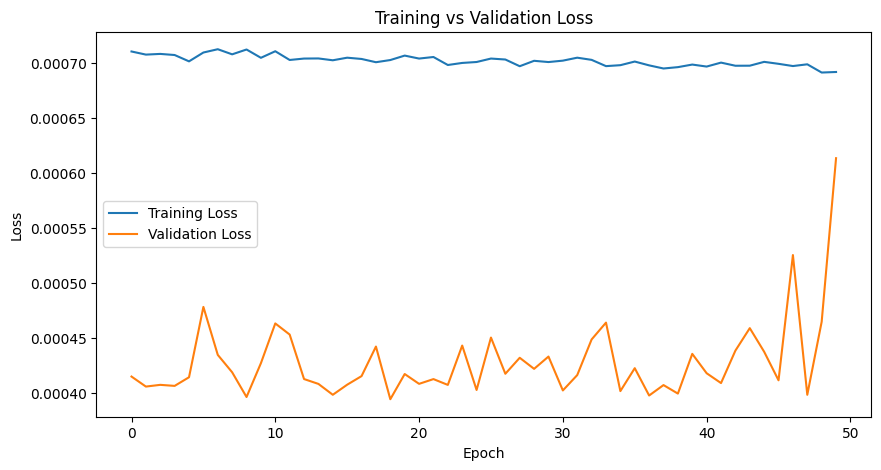

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [51]:
y_pred = model.predict(X_test)
import numpy as np

# Create dummy arrays with the correct number of features (4, matching scaled_data.shape[1])
dummy_pred = np.zeros((len(y_pred), scaled_data.shape[1]))
dummy_pred[:,0] = y_pred.flatten()

predicted_temp = scaler.inverse_transform(dummy_pred)[:,0]

dummy_true = np.zeros((len(y_test), scaled_data.shape[1]))
dummy_true[:,0] = y_test

actual_temp = scaler.inverse_transform(dummy_true)[:,0]

603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [52]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

rmse = np.sqrt(mean_squared_error(actual_temp, predicted_temp))
mae = mean_absolute_error(actual_temp, predicted_temp)
r2 = r2_score(actual_temp, predicted_temp)

print("RMSE :", rmse)
print("MAE  :", mae)
print("R2 Score :", r2)

RMSE : 1.2989261702307813
MAE  : 0.9559863059012477
R2 Score : 0.9790822037605879


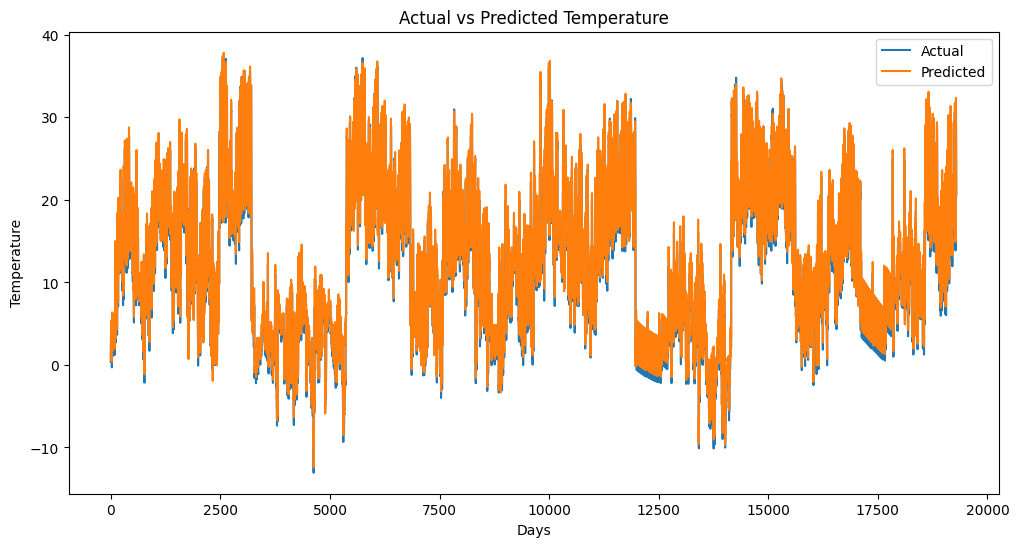

In [53]:
plt.figure(figsize=(12,6))

plt.plot(actual_temp, label="Actual")
plt.plot(predicted_temp, label="Predicted")

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Days")
plt.ylabel("Temperature")

plt.legend()

plt.show()

In [55]:
last_sequence = scaled_data[-7:]

future_predictions = []

for i in range(7):

    input_data = last_sequence.reshape(1,7,4)

    pred = model.predict(input_data, verbose=0)

    future_predictions.append(pred[0,0])

    new_row = last_sequence[-1].copy()
    new_row[0] = pred[0,0]

    last_sequence = np.vstack((last_sequence[1:], new_row))

In [57]:
future = np.zeros((7,4))
future[:,0] = future_predictions

forecast = scaler.inverse_transform(future)[:,0]

print(forecast)

[20.00704559 19.63788681 19.28872482 19.1920706  19.19889931 19.41081378
 19.75770934]


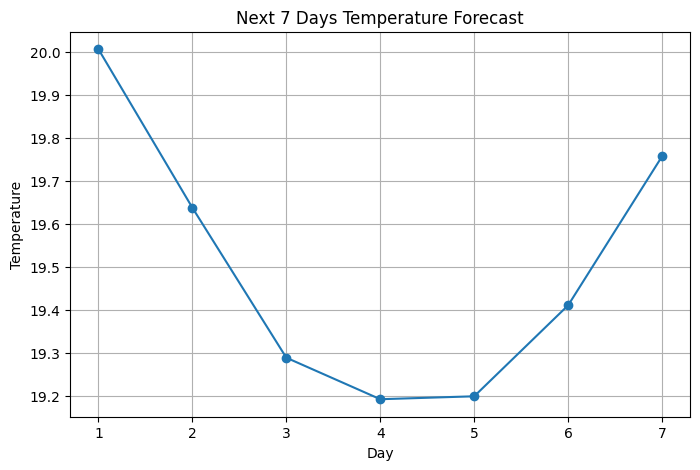

In [58]:
plt.figure(figsize=(8,5))

plt.plot(range(1,8), forecast, marker="o")

plt.title("Next 7 Days Temperature Forecast")
plt.xlabel("Day")
plt.ylabel("Temperature")

plt.grid(True)

plt.show()